#Mika5.1Tanh

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [ ]:
ticker = "MIKA.JK"
start_date = "2021-12-31"
end_date = "2023-12-18"

data = yf.download(ticker, start=start_date, end=end_date)

print(data)

[*********************100%%**********************]  1 of 1 completed
              Open    High     Low   Close    Adj Close    Volume
Date                                                             
2022-01-03  2260.0  2270.0  2230.0  2240.0  2181.010010  12318100
2022-01-04  2240.0  2280.0  2240.0  2250.0  2190.746826  12283700
2022-01-05  2250.0  2270.0  2220.0  2220.0  2161.536621  14831500
2022-01-06  2220.0  2280.0  2220.0  2270.0  2210.219971  14769900
2022-01-07  2270.0  2270.0  2220.0  2230.0  2171.273438  18583800
...            ...     ...     ...     ...          ...       ...
2023-12-11  2730.0  2760.0  2710.0  2740.0  2740.000000   8021900
2023-12-12  2750.0  2750.0  2670.0  2680.0  2680.000000   8366100
2023-12-13  2730.0  2760.0  2680.0  2730.0  2730.000000   8223000
2023-12-14  2730.0  2740.0  2680.0  2700.0  2700.000000   8926800
2023-12-15  2720.0  2770.0  2700.0  2760.0  2760.000000   9704800

[477 rows x 6 columns]


In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, kernel_initializer="glorot_uniform", input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 30, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_1 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_2 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_3 (LSTM)               (None, 50)                2

In [ ]:
# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 13s 70ms/step - loss: 0.0770
Epoch 2/200
22/22 [==============================] - 2s 69ms/step - loss: 0.0274
Epoch 3/200
22/22 [==============================] - 1s 67ms/step - loss: 0.0231
Epoch 4/200
22/22 [==============================] - 2s 86ms/step - loss: 0.0200
Epoch 5/200
22/22 [==============================] - 2s 88ms/step - loss: 0.0218
Epoch 6/200
22/22 [==============================] - 2s 85ms/step - loss: 0.0231
Epoch 7/200
22/22 [==============================] - 2s 69ms/step - loss: 0.0201
Epoch 8/200
22/22 [==============================] - 2s 72ms/step - loss: 0.0202
Epoch 9/200
22/22 [==============================] - 2s 70ms/step - loss: 0.0183
Epoch 10/200
22/22 [==============================] - 2s 69ms/step - loss: 0.0177
Epoch 11/200
22/22 [==============================] - 1s 68ms/step - loss: 0.0161
Epoch 12/200
22/22 [==============================] - 1s 46ms/step - loss: 0.0168
Epoch 13/200
22/22 [====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 18ms/step
Root mean squared error: 29.23901002354351


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 30ms/step
Root mean squared error: 50.30403745452333


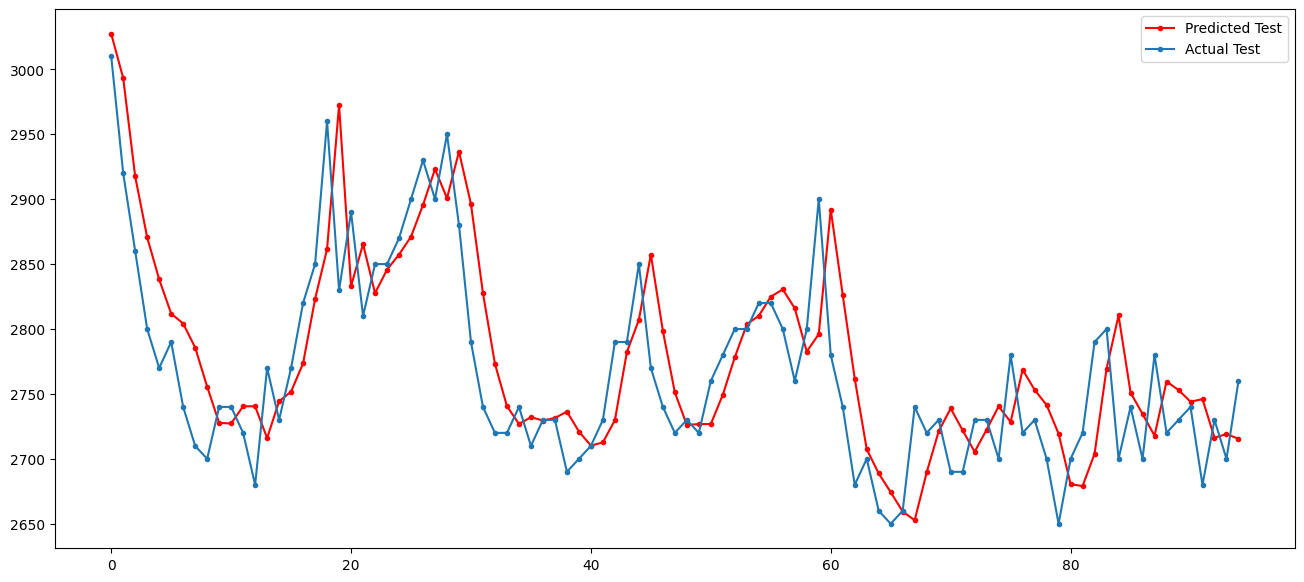

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 26ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     2745.726318
1   2023-12-19     2759.975342
2   2023-12-20     2770.163330
3   2023-12-21     2780.405518
4   2023-12-22     2791.285156
5   2023-12-25     2802.594727
6   2023-12-26     2813.819580
7   2023-12-27     2824.441162
8   2023-12-28     2834.052979
9   2023-12-29     2842.390869
10  2024-01-01     2849.398438
11  2024-01-02     2855.335693
12  2024-01-03     2860.367188
13  2024-01-04     2864.815674
14  2024-01-05     2868.898682
15  2024-01-08     2872.781494
16  2024-01-09     2876.654785
17  2024-01-10     2880.608398
18  2024-01-11     2884.756348
19  2024-01-12     2889.074707
20  2024-01-15     2893.428711
21  2024-01-16     2897.818115
